Question One

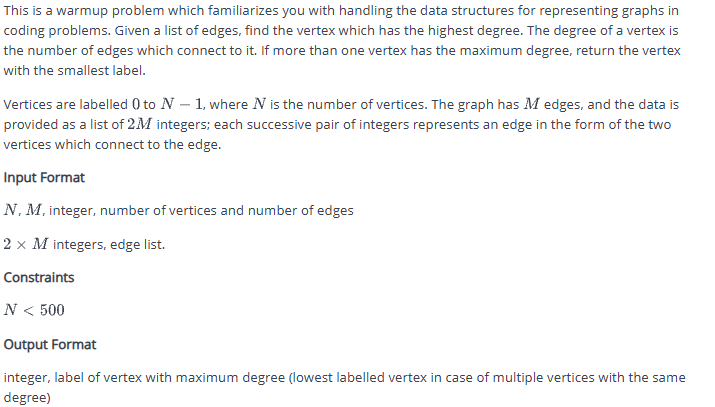

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'MaxDegreeVertex' function below.
#
# The function is expected to return an INTEGER.
# The function accepts following parameters:
#  1. INTEGER N
#  2. INTEGER M
#  3. INTEGER_ARRAY connections
#

def MaxDegreeVertex(N, M, connections):
    # Create a list to store degree for each vertex
    # We make size N and initialize all values to 0
    degree = [0] * N

    # Loop through the connections list two elements at a time
    # Each pair represents one edge
    for i in range(0, 2 * M, 2):
        # First vertex of the edge
        u = connections[i]
        
        # Second vertex of the edge
        v = connections[i + 1]
        
        # Increase degree of vertex u by 1
        degree[u] += 1
        
        # Increase degree of vertex v by 1
        degree[v] += 1

    # Find the maximum degree value in the list
    max_degree = max(degree)

    # Loop through all vertices from 0 to N-1
    for vertex in range(N):
        # If this vertex has the maximum degree
        if degree[vertex] == max_degree:
            # Return the first (smallest label) vertex with max degree
            return vertex

if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    first_multiple_input = input().rstrip().split()

    N = int(first_multiple_input[0])

    M = int(first_multiple_input[1])

    connections = list(map(int, input().rstrip().split()))

    maxVert = MaxDegreeVertex(N, M, connections)

    fptr.write(str(maxVert) + '\n')

    fptr.close()


Question Two

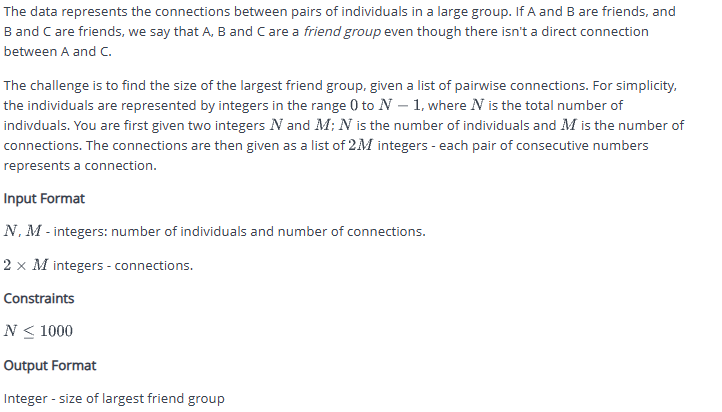

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'LargestFriendGroup' function below.
#
# The function is expected to return an INTEGER.
# The function accepts following parameters:
#  1. INTEGER N
#  2. INTEGER M
#  3. INTEGER_ARRAY connections
#
def LargestFriendGroup(N, M, connections):
    
    # Create empty graph list
    graph = []
    
    # Add N empty lists (one for each person)
    for i in range(N):
        graph.append([])
    
    # Build the graph from connections
    # Each pair represents a friendship
    for i in range(0, 2 * M, 2):
        u = connections[i]        # first person
        v = connections[i + 1]    # second person
        
        # Since friendship is mutual, add both directions
        graph[u].append(v)
        graph[v].append(u)
    
    # Keep track of visited people
    visited = [False] * N
    
    # Store the largest group size
    max_group_size = 0
    
    # DFS function to count group size
    def dfs(node):
        visited[node] = True      # mark as visited
        size = 1                  # count this person
        
        # Visit all friends
        for neighbor in graph[node]:
            if not visited[neighbor]:
                size += dfs(neighbor)
        
        return size
    
    # Check each person
    for i in range(N):
        if not visited[i]:
            group_size = dfs(i)
            if group_size > max_group_size:
                max_group_size = group_size
    
    return max_group_size

if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    first_multiple_input = input().rstrip().split()

    N = int(first_multiple_input[0])

    M = int(first_multiple_input[1])

    connections = list(map(int, input().rstrip().split()))

    groupSize = LargestFriendGroup(N, M, connections)

    fptr.write(str(groupSize) + '\n')

    fptr.close()


Question Three

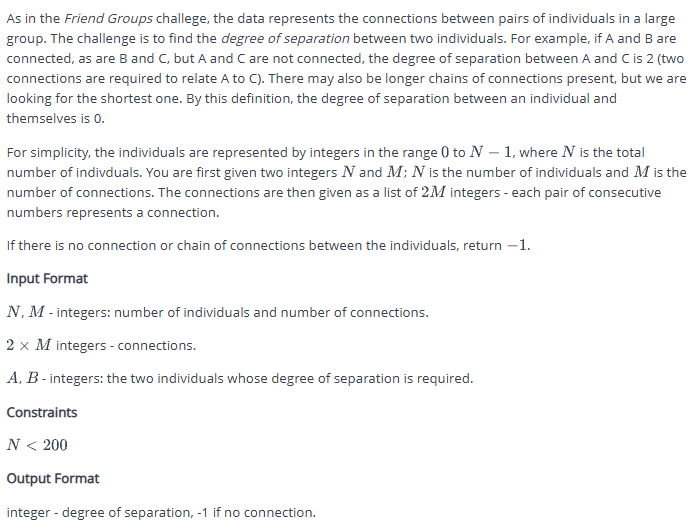

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'DegreeOfSeparation' function below.
#
# The function is expected to return an INTEGER.
# The function accepts following parameters:
#  1. INTEGER N
#  2. INTEGER M
#  3. INTEGER_ARRAY connections
#  4. INTEGER A
#  5. INTEGER B
#

def DegreeOfSeparation(N, M, connections, A, B):
  # If both people are the same
    if A == B:
        return 0
    
    # Create empty graph
    graph = []
    
    # Add N empty lists (one list per person)
    for i in range(N):
        graph.append([])
    
    # Build the graph from connections
    for i in range(0, 2 * M, 2):
        u = connections[i]        # first person
        v = connections[i + 1]    # second person
        
        # Friendship is mutual
        graph[u].append(v)
        graph[v].append(u)
    
    # Keep track of visited people
    visited = [False] * N
    
    # Create a queue for BFS
    queue = []
    
    # Add starting person A
    queue.append((A, 0))   # (person, distance)
    
    visited[A] = True      # mark A as visited
    
    # Start BFS
    while queue:
        current, distance = queue.pop(0)  # remove first element
        
        # Check all friends of current person
        for friend in graph[current]:
            
            # If we find person B
            if friend == B:
                return distance + 1
            
            # If not visited
            if not visited[friend]:
                visited[friend] = True
                queue.append((friend, distance + 1))
    
    # If we finish loop and never find B
    return -1
if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    first_multiple_input = input().rstrip().split()

    N = int(first_multiple_input[0])

    M = int(first_multiple_input[1])

    connections = list(map(int, input().rstrip().split()))

    second_multiple_input = input().rstrip().split()

    A = int(second_multiple_input[0])

    B = int(second_multiple_input[1])

    degree = DegreeOfSeparation(N, M, connections, A, B)

    fptr.write(str(degree) + '\n')

    fptr.close()


Question Four

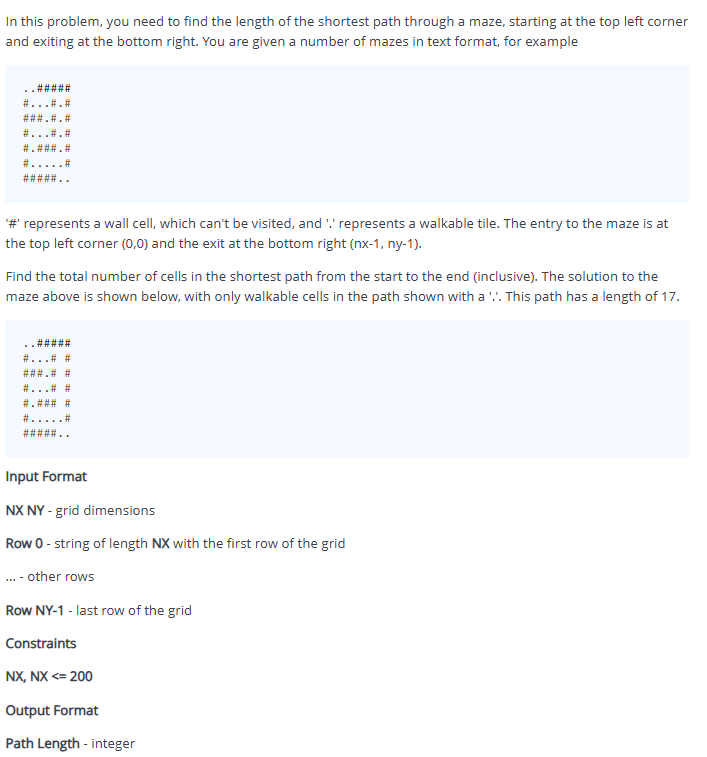

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'ShortestPath' function below.
#
# The function is expected to return an INTEGER.
# The function accepts following parameters:
#  1. INTEGER nx
#  2. INTEGER ny
#  3. STRING_ARRAY maze
#

def ShortestPath(nx, ny, maze):
    
    # If start or end is a wall, no path exists
    if maze[0][0] == '#' or maze[ny-1][nx-1] == '#':
        return -1
    
    # Directions: right, left, down, up
    directions = [(0,1), (0,-1), (1,0), (-1,0)]
    
    # Create visited grid
    visited = []
    for i in range(ny):
        visited.append([False] * nx)
    
    # Create queue for BFS
    queue = []
    
    # Add starting position 
    queue.append((0, 0, 1))   # distance starts at 1
    
    visited[0][0] = True
    
    # Start BFS
    while queue:
        row, col, dist = queue.pop(0)
        
        # If we reached bottom-right corner
        if row == ny - 1 and col == nx - 1:
            return dist
        
        # Try all 4 directions
        for dr, dc in directions:
            new_row = row + dr
            new_col = col + dc
            
            # Check boundaries
            if 0 <= new_row < ny and 0 <= new_col < nx:
                
                # If not visited and is walkable
                if not visited[new_row][new_col] and maze[new_row][new_col] == '.':
                    visited[new_row][new_col] = True
                    queue.append((new_row, new_col, dist + 1))
    
    # If no path found
    return -1

if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    first_multiple_input = input().rstrip().split()

    nx = int(first_multiple_input[0])

    ny = int(first_multiple_input[1])

    maze = []

    for _ in range(ny):
        maze_item = input()
        maze.append(maze_item)

    pathLength = ShortestPath(nx, ny, maze)

    fptr.write(str(pathLength) + '\n')

    fptr.close()
